In [15]:
%matplotlib inline
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [43]:
# Physics Engine
class SchwarzschildSpacetime:
    def __init__(self, M):
        self.M = M

    def null_geodesic(self, lmbda, y, b):
        t, r, phi, pr = y
        if r <= 2.001 * self.M:
            return [0, 0, 0, 0]
            
        dt_dl = 1.0 / (1.0 - 2.0 * self.M / r)
        dr_dl = pr
        dphi_dl = b / (r**2)
        dpr_dl = (b**2 / r**3) - (3.0 * self.M * b**2 / r**4)
        
        return [dt_dl, dr_dl, dphi_dl, dpr_dl]

    # Added 'direction' parameter here
    def trace_ray(self, source, b, direction='inward', lmbda_max=40, points=10000):
        try:
            # Passing 'direction' down to the light source
            y0 = source.get_initial_conditions(self.M, b, direction)
        except ValueError:
            return None 
            
        def hit_horizon(lmbda, y, b_arg):
            return y[1] - 2.001 * self.M
        hit_horizon.terminal = True
        
        eval_points = np.linspace(0, lmbda_max, points)
        
        solution = solve_ivp(
            self.null_geodesic, (0, lmbda_max), y0, args=(b,),
            method='RK45', t_eval=eval_points, events=hit_horizon,
            rtol=1e-6, atol=1e-6
        )
        return solution

class LightSource:
    def __init__(self, r0, phi0, label="Lamp"):
        self.r0 = r0
        self.phi0 = phi0
        self.label = label
        
    # Added 'direction' parameter here
    def get_initial_conditions(self, M, b, direction):
        V_eff = (1.0 - 2.0 * M / self.r0) * (b**2 / self.r0**2)
        if V_eff > 1.0:
            raise ValueError(f"Impact parameter b={b} too large.")
        
        pr0 = np.sqrt(1.0 - V_eff)
        
        # Flip the momentum sign if shooting inward
        if direction == 'inward':
            pr0 = -pr0
            
        return [0.0, self.r0, self.phi0, pr0]

In [44]:
# CELL 3
def find_intersections(data1, data2, eps_t=0.1, eps_s=0.25):
    """
    Finds points where light rays overlap in spacetime.
    data arrays shape: (N, 4) -> [Time, X, Y, Ray_ID]
    """
    # 1. Sort BOTH arrays chronologically (by Time)
    data1_sorted = data1[data1[:, 0].argsort()]
    data2_sorted = data2[data2[:, 0].argsort()]
    t2_sorted = data2_sorted[:, 0]
    
    intersections = []
    
    # NEW: Sets to keep track of rays that have already collided
    consumed_rays1 = set()
    consumed_rays2 = set()
    
    # 2. Step through Lamp 1's points in chronological order
    for pt1 in data1_sorted:
        t1, x1, y1, ray1_id = pt1
        
        # If this Lamp 1 ray already hit something previously, skip it!
        if ray1_id in consumed_rays1:
            continue
            
        # 3. Binary Search for time matches
        idx_lower = np.searchsorted(t2_sorted, t1 - eps_t, side='left')
        idx_upper = np.searchsorted(t2_sorted, t1 + eps_t, side='right')
        
        if idx_lower == idx_upper:
            continue
            
        candidates = data2_sorted[idx_lower:idx_upper]
        
        # 4. Spatial Check
        dist_sq = (candidates[:, 1] - x1)**2 + (candidates[:, 2] - y1)**2
        valid_candidates = candidates[dist_sq <= eps_s**2]
        
        if len(valid_candidates) > 0:
            # 5. Check if the Lamp 2 candidates are still active
            for cand in valid_candidates:
                ray2_id = cand[3]
                
                if ray2_id not in consumed_rays2:
                    # IT'S A HIT! First time these two rays met.
                    intersections.append((x1, y1))
                    
                    # Consume both rays so they are disconsidered going forward
                    consumed_rays1.add(ray1_id)
                    consumed_rays2.add(ray2_id)
                    break # Stop checking candidates for this specific pt1
            
    return np.array(intersections)

Tracing inward rays for Lamp 1...
Tracing inward rays for Lamp 2...
Finding first-contact spacetime intersections...


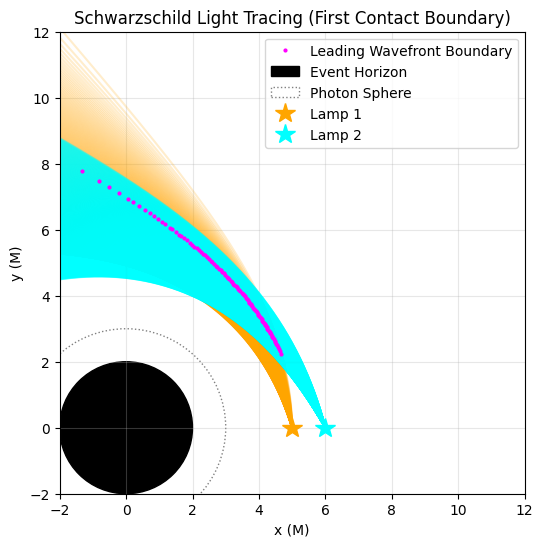

In [46]:
# Simulation and plot
M = 1.0
spacetime = SchwarzschildSpacetime(M)

lamp1 = LightSource(r0=5.0 * M, phi0=0.0, label="Lamp 1")
lamp2 = LightSource(r0=6.0 * M, phi0=0, label="Lamp 2")

b_values = np.linspace(6, 7, 1000) * M 

data_lamp1 = []
data_lamp2 = []

plt.figure(figsize=(6, 6))

print("Tracing inward rays for Lamp 1...")
# NEW: Using enumerate to get a unique Ray ID (i) for each ray
for i, b in enumerate(b_values):
    sol = spacetime.trace_ray(lamp1, b, direction='inward')
    if sol is not None:
        t, r, phi = sol.y[0], sol.y[1], sol.y[2]
        x, y = r * np.cos(phi), r * np.sin(phi)
        
        # Create an array of IDs matching the length of the time array
        ray_ids = np.full_like(t, i)
        
        # Stack 4 columns now: Time, X, Y, Ray_ID
        data_lamp1.extend(np.column_stack((t, x, y, ray_ids)))
        plt.plot(x, y, color='orange', alpha=0.2)
        
print("Tracing inward rays for Lamp 2...")
for i, b in enumerate(b_values):
    sol = spacetime.trace_ray(lamp2, b, direction='inward')
    if sol is not None:
        t, r, phi = sol.y[0], sol.y[1], sol.y[2]
        x, y = r * np.cos(phi), r * np.sin(phi)
        
        ray_ids = np.full_like(t, i)
        data_lamp2.extend(np.column_stack((t, x, y, ray_ids)))
        plt.plot(x, y, color='cyan', alpha=0.2)

data_lamp1 = np.array(data_lamp1)
data_lamp2 = np.array(data_lamp2)

print("Finding first-contact spacetime intersections...")
intersections = find_intersections(data_lamp1, data_lamp2, eps_t=0.1, eps_s=0.25)

if len(intersections) > 0:
    intersections = intersections[intersections[:, 0].argsort()]
    plt.plot(intersections[:, 0], intersections[:, 1], 'o', color='magenta', 
             linewidth=1, markersize=2, label='Leading Wavefront Boundary')
else:
    print("No intersections found. Try increasing eps_t, eps_s, or ray density.")

# Draw Environment
horizon = plt.Circle((0,0), 2*M, color='black', label='Event Horizon')
photon_sphere = plt.Circle((0,0), 3*M, color='gray', fill=False, linestyle=':', label='Photon Sphere')
plt.gca().add_patch(horizon)
plt.gca().add_patch(photon_sphere)

x1, y1 = lamp1.r0 * np.cos(lamp1.phi0), lamp1.r0 * np.sin(lamp1.phi0)
x2, y2 = lamp2.r0 * np.cos(lamp2.phi0), lamp2.r0 * np.sin(lamp2.phi0)

plt.plot(x1, y1, '*', color='orange', markersize=15, label='Lamp 1')
plt.plot(x2, y2, '*', color='cyan', markersize=15, label='Lamp 2')

plt.xlabel('x (M)')
plt.ylabel('y (M)')
plt.title('Schwarzschild Light Tracing (First Contact Boundary)')
plt.xlim(-2, 12)
plt.ylim(-2, 12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# Intersection find algorithm base on binary-search
def find_intersections(data1, data2, eps_t=0.1, eps_s=0.25):
    """
    Finds points where light rays overlap in spacetime.
    data arrays shape: (N, 3) -> [Time, X, Y]
    """
    data2_sorted = data2[data2[:, 0].argsort()]
    t2_sorted = data2_sorted[:, 0]
    
    intersections = []
    
    for pt1 in data1:
        t1, x1, y1 = pt1
        
        idx_lower = np.searchsorted(t2_sorted, t1 - eps_t, side='left')
        idx_upper = np.searchsorted(t2_sorted, t1 + eps_t, side='right')
        
        if idx_lower == idx_upper:
            continue
            
        candidates = data2_sorted[idx_lower:idx_upper]
        dist_sq = (candidates[:, 1] - x1)**2 + (candidates[:, 2] - y1)**2
        
        if np.any(dist_sq <= eps_s**2):
            intersections.append((x1, y1))
            
    return np.array(intersections)

Tracing inward rays for Lamp 1...
Tracing inward rays for Lamp 2...
Finding spacetime intersections...


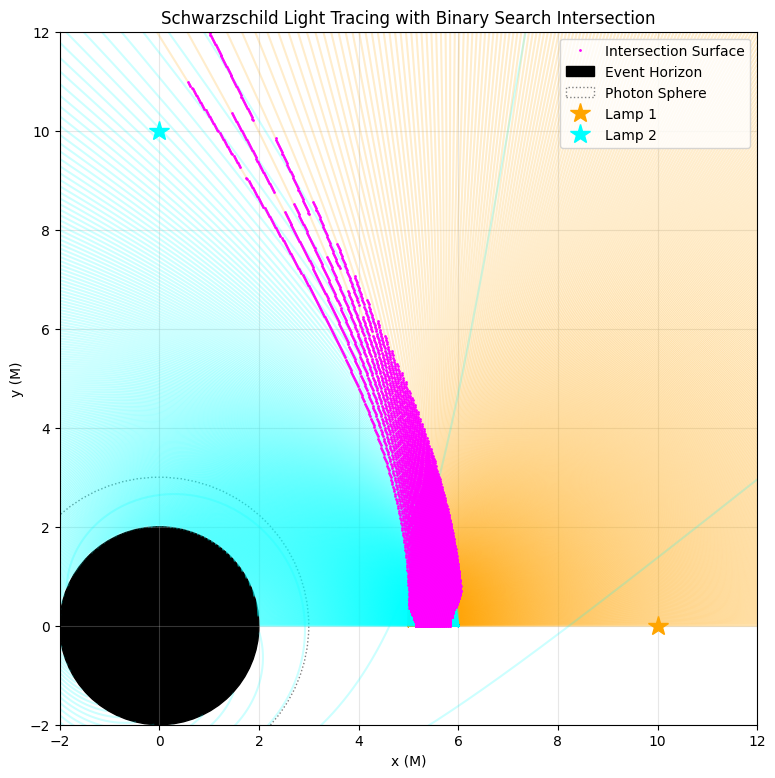

In [14]:
# Simulation and plot

M = 1.0
spacetime = SchwarzschildSpacetime(M)

lamp1 = LightSource(r0=5.0 * M, phi0=0.0, label="Lamp 1")
lamp2 = LightSource(r0=6.0 * M, phi0=0, label="Lamp 2")

b_values = np.linspace(0, 15, 1000) * M 

data_lamp1 = []
data_lamp2 = []

plt.figure(figsize=(9, 9))

print("Tracing inward rays for Lamp 1...")
for b in b_values:
    # Passed 'inward' direction here
    sol = spacetime.trace_ray(lamp1, b, direction='outward')
    if sol is not None:
        t, r, phi = sol.y[0], sol.y[1], sol.y[2]
        x, y = r * np.cos(phi), r * np.sin(phi)
        data_lamp1.extend(np.column_stack((t, x, y)))
        plt.plot(x, y, color='orange', alpha=0.2)
        
print("Tracing inward rays for Lamp 2...")
for b in b_values:
    # Passed 'inward' direction here
    sol = spacetime.trace_ray(lamp2, b, direction='inward')
    if sol is not None:
        t, r, phi = sol.y[0], sol.y[1], sol.y[2]
        x, y = r * np.cos(phi), r * np.sin(phi)
        data_lamp2.extend(np.column_stack((t, x, y)))
        plt.plot(x, y, color='cyan', alpha=0.2)

data_lamp1 = np.array(data_lamp1)
data_lamp2 = np.array(data_lamp2)

print("Finding spacetime intersections...")
intersections = find_intersections(data_lamp1, data_lamp2, eps_t=1, eps_s=0.1)

if len(intersections) > 0:
    intersections = intersections[intersections[:, 0].argsort()]
    plt.plot(intersections[:, 0], intersections[:, 1], 'o', color='magenta', 
             linewidth=1, markersize=1, label='Intersection Surface')
else:
    print("No intersections found. Try increasing eps_t, eps_s, or ray density.")

# Draw Environment
horizon = plt.Circle((0,0), 2*M, color='black', label='Event Horizon')
photon_sphere = plt.Circle((0,0), 3*M, color='gray', fill=False, linestyle=':', label='Photon Sphere')
plt.gca().add_patch(horizon)
plt.gca().add_patch(photon_sphere)

plt.plot(10, 0, '*', color='orange', markersize=15, label='Lamp 1')
plt.plot(0, 10, '*', color='cyan', markersize=15, label='Lamp 2')

plt.xlabel('x (M)')
plt.ylabel('y (M)')
plt.title('Schwarzschild Light Tracing with Binary Search Intersection')
plt.xlim(-2, 12)
plt.ylim(-2, 12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()